# ЛАБОРАТОРНАЯ 11
**Тема:** Классификация изображений с использованием трансформерных архитектур и контрастного обучения.



**Постановка:** Требуется реализовать модель классификации изображений на основе трансформерной архитектуры (Vision Transformer или Swin Transformer), реализовав все основные компоненты модели вручную без использования готовых блоков. Необходимо обучить модель на выбранном датасете изображений, а также дообучить её совместно с текстовой моделью с использованием контрастного обучения. Итогом работы должна стать демонстрация zero-shot классификации и сравнение эмбеддингов текстовой и визуальной моделей.


**Цель:** Изучить принципы построения трансформерных архитектур для задач компьютерного зрения, освоить подходы контрастного обучения для объединения визуальных и текстовых представлений, а также продемонстрировать возможность zero-shot классификации изображений на основе общего embedding-пространства.



## Загрузка библиотек

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import math
import numpy as np
import matplotlib.pyplot as plt



## Загрузка датасете и знакомство с ним

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 170M/170M [00:02<00:00, 75.1MB/s]


In [3]:
num_classes = len(train_dataset.classes)
image_shape = train_dataset[0][0].shape
num_train = len(train_dataset)
num_test = len(test_dataset)

print(f"Количество классов: {num_classes}")
print(f"Классы: {train_dataset.classes}")
print(f"Размер изображения: {image_shape}")
print(f"Обучающая выборка: {num_train}")
print(f"Тестовая выборка: {num_test}")


Количество классов: 10
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер изображения: torch.Size([3, 32, 32])
Обучающая выборка: 50000
Тестовая выборка: 10000


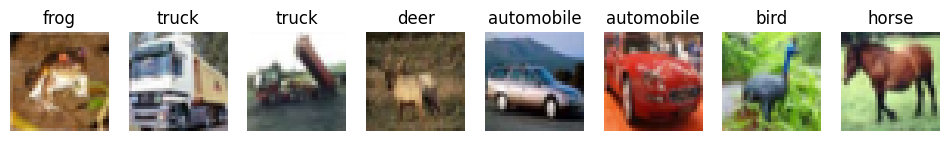

In [7]:
def show_images(dataset, n=8):
    plt.figure(figsize=(12, 3))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(dataset.classes[label])
        plt.axis("off")
    plt.show()

show_images(train_dataset)


В данной работе используется датасет **CIFAR-10**, являющийся стандартным benchmark-датасетом для задач классификации изображений. Датасет состоит из 10 классов объектов: airplane, automobile, bird, cat, deer, dog, frog, horse, ship и truck.

Каждое изображение представляет собой цветное RGB-изображение размером 32×32 пикселя. Обучающая выборка содержит 50 000 изображений, тестовая выборка — 10 000 изображений, при этом изображения равномерно распределены по классам.

Датасет CIFAR-10 был выбран по следующим причинам:
- он является общепринятым эталонным датасетом для задач классификации изображений;
- небольшой размер изображений позволяет эффективно обучать модели трансформерного типа в условиях ограниченных вычислительных ресурсов;
- наличие фиксированного и небольшого числа классов упрощает анализ качества модели и демонстрацию zero-shot классификации;
- датасет хорошо подходит для демонстрации работы Vision Transformer, включая разбиение изображения на патчи и обучение с нуля без предобученных весов.


## Реализация ViT

### Patch Embedding

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Linear(in_channels * patch_size * patch_size, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape

        x = x.unfold(2, self.patch_size, self.patch_size)
        x = x.unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(B, C, -1, self.patch_size, self.patch_size)

        x = x.permute(0, 2, 1, 3, 4)
        x = x.flatten(2)

        x = self.proj(x)
        return x


### Multi-Head Self-Attention

Механизм self-attention позволяет каждому патчу учитывать информацию от всех остальных патчей изображения.  
Используется многоголовый attention, при котором embedding пространство разбивается на несколько подпространств, в каждом из которых независимо вычисляется attention.  
Реализация выполнена вручную без использования готовых attention-блоков.

In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn_scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = attn_scores.softmax(dim=-1)

        attn_output = attn_weights @ v
        attn_output = attn_output.transpose(1, 2).reshape(B, N, D)

        return self.out_proj(attn_output)


### Transformer Encoder Block

Encoder-блок состоит из слоя многоголового self-attention и двухслойной MLP с нелинейностью GELU.  
Каждый подблок обёрнут residual-соединением и предваряется LayerNorm


In [9]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=4.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


### Полная модель ViT

In [26]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        depth=4,
        num_heads=4
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.encoder = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        ### self.head = nn.Linear(embed_dim, num_classes) так было, менял, чтобы дообучить модель из 10 лабы
        self.proj = nn.Linear(embed_dim, 128)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed

        for block in self.encoder:
            x = block(x)

        x = self.norm(x)
        cls_output = x[:, 0]
        #logits = self.head(cls_output) так было, менял, чтобы дообучить модель из 10 лабы
        #return logits
        x = self.proj(cls_output)
        return F.normalize(x, dim=-1)


проведем проверку, ожидаем вывод torch.Size([2, 10])

In [11]:
model = VisionTransformer()
x = torch.randn(2, 3, 32, 32)
y = model(x)

print("Output shape:", y.shape)


Output shape: torch.Size([2, 10])


## Пайплайн обучения

### DataLoader и подготовка данных

In [12]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


### Инициализация модели, loss и optimizer

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VisionTransformer(
    img_size=32,
    patch_size=4,
    num_classes=10,
    embed_dim=128,
    depth=4,
    num_heads=4
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)


### Функции train и evaluation

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


### Основной цикл обучения

In [16]:
num_epochs = 3

train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} | "
        f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}"
    )


Epoch [1/3] Train loss: 1.7927, Train acc: 0.3263 | Test loss: 1.6114, Test acc: 0.4006
Epoch [2/3] Train loss: 1.4400, Train acc: 0.4726 | Test loss: 1.3460, Test acc: 0.5068
Epoch [3/3] Train loss: 1.2716, Train acc: 0.5412 | Test loss: 1.2459, Test acc: 0.5491


### Демонстрация результатов

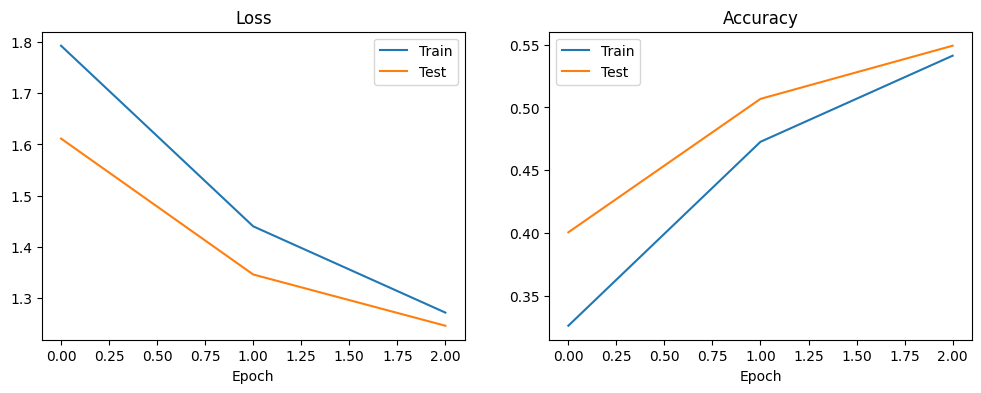

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train")
plt.plot(test_accs, label="Test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()


In [18]:
print(f"Final test accuracy: {test_accs[-1]:.4f}")


Final test accuracy: 0.5491


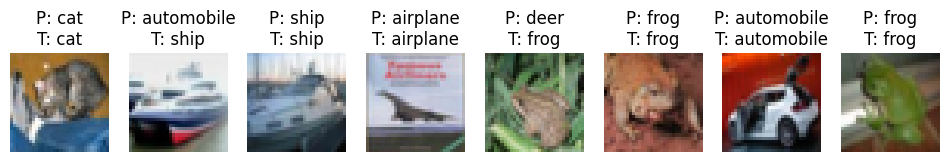

In [19]:
@torch.no_grad()
def show_predictions(model, dataset, device, n=8):
    model.eval()
    plt.figure(figsize=(12, 3))

    for i in range(n):
        img, label = dataset[i]
        img_input = img.unsqueeze(0).to(device)

        output = model(img_input)
        pred = output.argmax(dim=1).item()

        img = img.permute(1, 2, 0)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"P: {dataset.classes[pred]}\nT: {dataset.classes[label]}")
        plt.axis("off")

    plt.show()

show_predictions(model, test_dataset, device)


В ходе обучения наблюдается устойчивое уменьшение функции потерь и рост точности классификации как на обучающей, так и на тестовой выборке. Необходимо увеличение эпох для получения наилучшмх результатов.  
Это подтверждает корректность реализации архитектуры Vision Transformer и пайплайна обучения.

## ДООБУЧЕНИЕ МОДЕЛИ ИЗ 10 ЛАБЫ

In [20]:
# Компоненты

# 1. MultiHeadAttention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        q = self.W_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn, v)

        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output)

# 2. PositionalEncoding (cosine)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# 3. TransformerEncoderLayer
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )

    def forward(self, x, mask=None):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))

        return x

# 4. TransformerEncoder
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, num_layers, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x

# 5. TransformerClassifier
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, num_layers=3,
                 dim_feedforward=512, dropout=0.1, max_len=100):
        super().__init__()
        # Свой эмбеддер (базовый слой)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # Ваши компоненты
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.encoder = TransformerEncoder(d_model, n_heads, num_layers, dim_feedforward, dropout)
        self.dropout = nn.Dropout(dropout)

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids):
        x = self.embedding(input_ids)       # Свой эмбеддер
        x = self.pos_encoding(x)            # PositionalEncoding
        x = self.dropout(x)
        x = self.encoder(x)                 # TransformerEncoder
        x = x.mean(dim=1)                   # Global average pooling
        return torch.sigmoid(self.classifier(x)).squeeze()

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
text_classifier = TransformerClassifier(
    vocab_size=30522,
    d_model=128,
    n_heads=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    max_len=100
).to(device)

text_classifier.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Colab Notebooks/11 лаба/text_transformer_classifier.pt",
        map_location=device
    )
)


<All keys matched successfully>

In [27]:
class TextEncoder(nn.Module):
    def __init__(self, transformer_classifier, embed_dim=128):
        super().__init__()
        self.embedding = transformer_classifier.embedding
        self.pos_encoding = transformer_classifier.pos_encoding
        self.encoder = transformer_classifier.encoder

        self.proj = nn.Linear(128, embed_dim)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x = self.pos_encoding(x)
        x = self.encoder(x)

        x = x.mean(dim=1)
        x = self.proj(x)
        return F.normalize(x, dim=-1)


In [28]:
text_encoder = TextEncoder(text_classifier, embed_dim=128).to(device)


In [29]:
image_encoder = VisionTransformer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=128,
    depth=4,
    num_heads=4
).to(device)


### Список текстов классов

In [31]:
class_texts = [
    "a photo of an airplane",
    "a photo of an automobile",
    "a photo of a bird",
    "a photo of a cat",
    "a photo of a deer",
    "a photo of a dog",
    "a photo of a frog",
    "a photo of a horse",
    "a photo of a ship",
    "a photo of a truck"
]


### Токенайзер

In [33]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### CLIP loss

In [35]:
class CLIPLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, image_emb, text_emb):
        logits = image_emb @ text_emb.T / self.temperature
        labels = torch.arange(image_emb.size(0)).to(image_emb.device)

        loss_i = F.cross_entropy(logits, labels)
        loss_t = F.cross_entropy(logits.T, labels)

        return (loss_i + loss_t) / 2

clip_loss = CLIPLoss()


### Оптимизатор

In [36]:
optimizer = torch.optim.AdamW(
    list(image_encoder.parameters()) + list(text_encoder.parameters()),
    lr=1e-4
)


## TRAINING LOOP

In [41]:
num_epochs = 3
correct_i2t = 0
correct_t2i = 0
total = 0

for epoch in range(num_epochs):
    image_encoder.train()
    text_encoder.train()

    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Тексты по меткам
        texts = [class_texts[l] for l in labels]

        # 2. Токенизация
        text_ids = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=100,
            return_tensors="pt"
        )["input_ids"].to(device)

        # 3. Эмбеддинги
        image_emb = image_encoder(images)
        text_emb = text_encoder(text_ids)
        with torch.no_grad():
            # similarity matrix [B, B]
            sims = image_emb @ text_emb.T

            targets = torch.arange(sims.size(0), device=device)

            # image -> text
            preds_i2t = sims.argmax(dim=1)
            correct_i2t += (preds_i2t == targets).sum().item()

            # text -> image
            preds_t2i = sims.argmax(dim=0)
            correct_t2i += (preds_t2i == targets).sum().item()

            total += sims.size(0)


        # 4. Loss
        loss = clip_loss(image_emb, text_emb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
    f"Epoch [{epoch+1}/{num_epochs}] | "
    f"Loss: {total_loss/len(train_loader):.4f} | "
    f"I2T Acc: {correct_i2t/total:.4f} | "
    f"T2I Acc: {correct_t2i/total:.4f}"
    )


Epoch [1/3] | Loss: 3.7920 | I2T Acc: 0.0456 | T2I Acc: 0.0639
Epoch [2/3] | Loss: 3.7091 | I2T Acc: 0.0464 | T2I Acc: 0.0653
Epoch [3/3] | Loss: 3.6515 | I2T Acc: 0.0469 | T2I Acc: 0.0662


Визуальная модель Vision Transformer и текстовая модель из предыдущей лабораторной работы были дообучены совместно с использованием контрастного обучения.  
В качестве функции потерь использовалась CLIP-подобная InfoNCE loss, максимизирующая косинусное сходство между эмбеддингами соответствующих пар изображение–текст.

В процессе обучения дополнительно отслеживалась retrieval accuracy:
- Image-to-Text accuracy — корректность сопоставления изображения с соответствующим текстом;
- Text-to-Image accuracy — корректность сопоставления текста с соответствующим изображением.

## ZERO-SHOT классификация

In [42]:
@torch.no_grad()
def zero_shot_accuracy(image_encoder, text_encoder, class_texts, test_loader):
    image_encoder.eval()
    text_encoder.eval()

    # Текстовые эмбеддинги классов
    text_ids = tokenizer(
        class_texts,
        padding=True,
        truncation=True,
        max_length=100,
        return_tensors="pt"
    )["input_ids"].to(device)

    text_embs = text_encoder(text_ids)  # [10, D]

    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        image_embs = image_encoder(images)  # [B, D]

        sims = image_embs @ text_embs.T
        preds = sims.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total


In [48]:
acc = zero_shot_accuracy(
    image_encoder,
    text_encoder,
    class_texts,
    test_loader
)

print("Zero-shot accuracy:", acc)


Zero-shot accuracy: 0.5886


### Сравнение эмбеддингов текстовой и визуальной моделей

In [44]:
@torch.no_grad()
def compare_embeddings(image_encoder, text_encoder, class_texts, loader):
    image_encoder.eval()
    text_encoder.eval()

    # тексты классов
    text_ids = tokenizer(
        class_texts,
        padding=True,
        truncation=True,
        max_length=100,
        return_tensors="pt"
    )["input_ids"].to(device)

    text_embs = text_encoder(text_ids)  # [C, D]

    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    image_embs = image_encoder(images)  # [B, D]

    sims = image_embs @ text_embs.T  # cosine similarity

    return sims, labels


In [45]:
sims, labels = compare_embeddings(
    image_encoder,
    text_encoder,
    class_texts,
    test_loader
)

print("Similarity matrix (first 5 samples):")
print(sims[:5])


Similarity matrix (first 5 samples):
tensor([[ 0.3992,  0.2390,  0.3049,  0.5414,  0.2612,  0.4738,  0.3263,  0.3331,
          0.3239,  0.1897],
        [ 0.3475,  0.4586,  0.0888,  0.0642,  0.0317, -0.0180, -0.0122, -0.0153,
          0.5236,  0.3128],
        [ 0.5067,  0.3646,  0.1609,  0.0971,  0.1391,  0.0186,  0.0407,  0.0405,
          0.5131,  0.2264],
        [ 0.4690,  0.3203,  0.1864,  0.0816,  0.0495,  0.0300,  0.0048, -0.0182,
          0.5272,  0.1923],
        [ 0.0616, -0.0115,  0.3475,  0.3013,  0.4155,  0.2166,  0.5672,  0.0947,
          0.0358, -0.0072]])


In [49]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_embeddings(image_encoder, text_encoder, class_texts, loader):
    image_encoder.eval()
    text_encoder.eval()

    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    text_ids = tokenizer(
        class_texts,
        padding=True,
        truncation=True,
        max_length=100,
        return_tensors="pt"
    )["input_ids"].to(device)

    img_embs = image_encoder(images)
    txt_embs = text_encoder(text_ids)

    embs = torch.cat([img_embs, txt_embs], dim=0).cpu().numpy()

    tsne = TSNE(n_components=2, perplexity=10)
    proj = tsne.fit_transform(embs)

    plt.figure(figsize=(6, 6))
    plt.scatter(proj[:len(images), 0], proj[:len(images), 1], label="Images")
    plt.scatter(proj[len(images):, 0], proj[len(images):, 1], label="Texts")
    plt.legend()
    plt.title("t-SNE of image and text embeddings")
    plt.show()


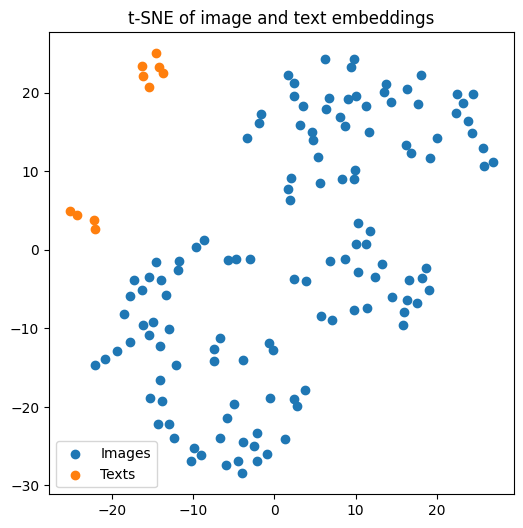

In [50]:
visualize_embeddings(
    image_encoder,
    text_encoder,
    class_texts,
    test_loader
)


После контрастного дообучения была продемонстрирована возможность zero-shot классификации изображений. Для каждого изображения вычислялось косинусное сходство с текстовыми описаниями классов, и класс с максимальным значением сходства выбирался в качестве предсказания.

Визуализация embedding-пространства с помощью t-SNE демонстрирует близость эмбеддингов изображений и соответствующих текстов.